AI Assistance: OpenAI ChatGPT and Anthropic's Claude were used for code debugging, code generation, code organization, and code methodological brainstorming. All final modeling, implementation, validation, commentary, and interpretation were performed and verified by the authors.

# LSTM baseline + validation-based grid search + test scoring

NOTE: This notebook was run on a Google Colab GPU. It will likely take several hours to run if done on a CPU.

# I. Configuration

In [ ]:
import json
import time
import itertools
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## Platform / path configuration

In [ ]:
from google.colab import files
uploaded = files.upload()  # opens a plain browser file picker, no Google Drive sign-in involved


In [ ]:
platform = 'colab_manual'  # skips the Drive branch entirely

PROCESSED_DIR = Path('/content/')
MODELS_DIR = Path('/content/models')
MODELS_DIR.mkdir(parents=True, exist_ok=True)

assert PROCESSED_DIR.exists(), f'{PROCESSED_DIR} not found - upload/extract files here first'
print(f'PROCESSED_DIR: {PROCESSED_DIR.resolve()}')
print(f'MODELS_DIR: {MODELS_DIR.resolve()}')

PROCESSED_DIR: /content
MODELS_DIR: /content/models


## Device

`cudnn.deterministic=True` narrows (but does not fully guarantee) run-to-run GPU variance for LSTM
kernels. This is why the grid search (Section VI) captures each config's best-epoch weights
directly rather than relying on a reproducible retrain — see Section VII.

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

if device.type == 'cuda':
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: Tesla T4


## Grid / training constants

The 36-config grid (layers x units x learning rate) is kept conservative on purpose, even with GPU
access, to stay light on Colab compute-unit spend.

In [ ]:
SEED = 42
EPOCHS = 50
BATCH_SIZE = 64
PATIENCE = 7
MIN_DELTA = 1e-4

LAYER_GRID = [1, 2, 3, 4]
UNIT_GRID = [16, 64, 256]
LR_GRID = [1e-4, 1e-3, 1e-2]

BASELINE_NUM_LAYERS = 1
BASELINE_HIDDEN = 64
BASELINE_LR = 1e-3

GRID_RESULTS_PATH = PROCESSED_DIR / 'lstm_grid_search_results.csv'
RESULTS_CSV_PATH = PROCESSED_DIR / 'lstm_train_val_test_results.csv'

n_configs = len(LAYER_GRID) * len(UNIT_GRID) * len(LR_GRID)
print(f'{n_configs} grid configs scoped (layers={LAYER_GRID}, hidden={UNIT_GRID}, lr={LR_GRID})')

36 grid configs scoped (layers=[1, 2, 3, 4], hidden=[16, 64, 256], lr=[0.0001, 0.001, 0.01])


# II. Function definitions

## 1. `load_lstm_dataset`

In [ ]:
def load_lstm_dataset(split):
    """
    Load the LSTM sequence dataset for a given split, via PROCESSED_DIR (respects the platform
    switch above).

    Parameters
    ----------
    split : str
        'train', 'validation', or 'test'.

    Returns
    -------
    X : np.ndarray, shape (n, 24, 22)
    y : np.ndarray, shape (n,)
    timestamps : np.ndarray, shape (n,), dtype datetime64[ns]
    channels : list of str, length 22
    """
    base = PROCESSED_DIR / f'lstm_{split}'

    X = np.load(f'{base}_X.npy')
    y = np.load(f'{base}_y.npy')
    timestamps = np.load(f'{base}_timestamps.npy')
    with open(f'{base}_channels.json') as f:
        channels = json.load(f)

    print(f'--- load_lstm_dataset: {split} ---')
    print(f'X.shape: {X.shape}, y.shape: {y.shape}, timestamps.shape: {timestamps.shape}')
    print(f'Channels ({len(channels)}): {channels}')

    return X, y, timestamps, channels

## 2. `preview_lstm_dataset`

In [ ]:
def preview_lstm_dataset(X, y, timestamps, channels, i=0):
    """
    Render sequence i as a labeled DataFrame alongside its target and timestamp, for a quick
    visual sanity check before training.

    Parameters
    ----------
    X : np.ndarray, shape (n, 24, n_channels)
    y : np.ndarray, shape (n,)
    timestamps : np.ndarray, shape (n,)
    channels : list of str
    i : int, default 0
        Index of the sequence to preview.
    """
    preview = pd.DataFrame(X[i], columns=channels)
    preview.index.name = 'hour_offset (H-24 ... H-1)'
    print(f'--- Sequence preview (index {i}, target hour {timestamps[i]}) ---')
    print(preview)
    print(f'  -> target kp_index = {y[i]:.2f}')

## 3. `fit_scaler` / `apply_scaler`

In [ ]:
def fit_scaler(X_train):
    """
    Fit a StandardScaler on the train set only, one mean/scale pair per channel.

    Reshapes (n, 24, n_channels) to (n*24, n_channels) so every hourly observation across every
    sequence counts as one row for fitting - matches 07b_lstm_baseline.ipynb's scaling approach.
    Only one scaler is needed here (fit on the real train set, applied to real
    train/validation/test) - unlike an earlier draft plan for LSTM tuning, which needed two
    scalers because it had to carve a synthetic validation subset out of train.

    Parameters
    ----------
    X_train : np.ndarray, shape (n, 24, n_channels)

    Returns
    -------
    scaler : StandardScaler
        Fitted on train only.
    """
    n, t, c = X_train.shape
    scaler = StandardScaler()
    scaler.fit(X_train.reshape(n * t, c))

    print('--- fit_scaler: per-channel audit ---')
    print('Mean (first 5 channels):', np.round(scaler.mean_[:5], 4))
    print('Scale (first 5 channels):', np.round(scaler.scale_[:5], 4))

    return scaler


def apply_scaler(scaler, X):
    """
    Apply an already-fitted StandardScaler to a (n, 24, n_channels) array.

    Parameters
    ----------
    scaler : StandardScaler
        Returned by fit_scaler.
    X : np.ndarray, shape (n, 24, n_channels)

    Returns
    -------
    X_scaled : np.ndarray, shape (n, 24, n_channels), dtype float32
    """
    n, t, c = X.shape
    X_scaled = scaler.transform(X.reshape(n * t, c)).reshape(n, t, c).astype(np.float32)
    return X_scaled

## 4. `LSTMRegressor`

In [ ]:
class LSTMRegressor(nn.Module):
    """
    LSTM regressor: a stack of LSTM layers feeding a linear output head on the final layer's
    final hidden state. One class serves both the untuned baseline (num_layers=1) and every
    grid-search config.

    Parameters
    ----------
    input_size : int
        Number of channels per timestep.
    hidden_size : int, default 64
    num_layers : int, default 1
    dropout : float, default 0.2
        Applied between stacked LSTM layers only - forced to 0.0 when num_layers==1, since
        nn.LSTM's dropout has no effect (and triggers a warning) with a single layer.
    """

    def __init__(self, input_size, hidden_size=64, num_layers=1, dropout=0.2):
        super().__init__()
        lstm_dropout = dropout if num_layers > 1 else 0.0
        self.lstm = nn.LSTM(
            input_size=input_size, hidden_size=hidden_size, num_layers=num_layers,
            dropout=lstm_dropout, batch_first=True,
        )
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        return self.head(h_n[-1])

## 5. `train_model`

In [ ]:
def train_model(model, X_train, y_train, X_val=None, y_val=None, epochs=50, batch_size=64,
                 lr=1e-3, patience=None, min_delta=1e-4, device=None):
    """
    Train an LSTMRegressor with Adam/MSELoss on shuffled mini-batches.

    When X_val/y_val are given, computes full-batch validation MSE after every epoch and appends
    it to history['val_loss']. When patience is also given, tracks the best-val-loss state_dict
    (moved to CPU) and stops early after `patience` epochs without a >min_delta improvement,
    reloading the best state before returning. Called with no X_val/patience for a plain
    full-train run (no validation split), matching 07b_lstm_baseline.ipynb's original untuned
    recipe exactly.

    Parameters
    ----------
    model : LSTMRegressor
    X_train : np.ndarray, shape (n, 24, n_channels)
    y_train : np.ndarray, shape (n,)
    X_val, y_val : np.ndarray, optional
        Held-out validation arrays for per-epoch monitoring / early stopping.
    epochs : int, default 50
    batch_size : int, default 64
    lr : float, default 1e-3
    patience : int, optional
        Epochs to wait for a val_loss improvement before stopping early. Ignored if X_val is None.
    min_delta : float, default 1e-4
        Minimum decrease in val_loss counted as an improvement.
    device : torch.device, optional
        Defaults to CPU if not given.

    Returns
    -------
    model : LSTMRegressor
        The trained model (in eval mode) - reloaded to its best-val-loss state if patience fired.
    history : dict
        {'train_loss': [...], 'val_loss': [...] (if X_val given), 'stopped_epoch': int}
    """
    device = device or torch.device('cpu')
    model = model.to(device)

    X_train_t = torch.from_numpy(X_train).float().to(device)
    y_train_t = torch.from_numpy(y_train).float().unsqueeze(1).to(device)
    loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)

    has_val = X_val is not None and y_val is not None
    if has_val:
        X_val_t = torch.from_numpy(X_val).float().to(device)
        y_val_t = torch.from_numpy(y_val).float().unsqueeze(1).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    history = {'train_loss': []}
    if has_val:
        history['val_loss'] = []

    best_val_loss = float('inf')
    best_state = None
    epochs_without_improvement = 0
    stopped_epoch = epochs

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_losses = []
        for X_batch, y_batch in loader:
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()
            epoch_losses.append(loss.item())
        history['train_loss'].append(float(np.mean(epoch_losses)))

        if has_val:
            model.eval()
            with torch.no_grad():
                val_loss = criterion(model(X_val_t), y_val_t).item()
            history['val_loss'].append(val_loss)

            if patience is not None:
                if val_loss < best_val_loss - min_delta:
                    best_val_loss = val_loss
                    best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                    epochs_without_improvement = 0
                else:
                    epochs_without_improvement += 1
                    if epochs_without_improvement >= patience:
                        stopped_epoch = epoch
                        break

    if patience is not None and has_val and best_state is not None:
        model.load_state_dict(best_state)

    history['stopped_epoch'] = stopped_epoch
    model.eval()

    print(f'--- train_model: {stopped_epoch} epoch(s) run (ceiling {epochs}) ---')
    print(f"Final train_loss: {history['train_loss'][-1]:.4f}")
    if has_val:
        suffix = f' (best: {best_val_loss:.4f})' if patience is not None else ''
        print(f"Final val_loss: {history['val_loss'][-1]:.4f}{suffix}")

    return model, history

## 6. `evaluate_model`

In [ ]:
def evaluate_model(model, X, y, label='Test', device=None):
    """
    Evaluate a trained LSTMRegressor with RMSE, MAE, and R2 - the same sklearn.metrics functions
    used by 07b_lstm_baseline.ipynb and 07d_linear_regression_train_val_test.ipynb - via a
    full-batch forward pass on `device`.

    Parameters
    ----------
    model : LSTMRegressor
    X : np.ndarray, shape (n, 24, n_channels)
    y : np.ndarray, shape (n,)
    label : str, default 'Test'
        Printed alongside the metrics, so a validation-set score is never misread as a test touch.
    device : torch.device, optional
        Defaults to CPU if not given.

    Returns
    -------
    metrics : dict
        {'n': ..., 'rmse': ..., 'mae': ..., 'r2': ...}
    y_pred : np.ndarray, shape (n,)
    """
    device = device or torch.device('cpu')
    model.eval()
    with torch.no_grad():
        X_tensor = torch.from_numpy(X).float().to(device)
        y_pred = model(X_tensor).cpu().numpy().flatten()

    rmse = np.sqrt(mean_squared_error(y, y_pred))
    mae = mean_absolute_error(y, y_pred)
    r2 = r2_score(y, y_pred)

    print(f'--- evaluate_model: {label} ---')
    print(f'n:    {len(y)}')
    print(f'RMSE: {rmse:.4f}')
    print(f'MAE:  {mae:.4f}')
    print(f'R2:   {r2:.4f}')

    return {'n': len(y), 'rmse': rmse, 'mae': mae, 'r2': r2}, y_pred

## 7. `plot_training_loss`

In [ ]:
def plot_training_loss(history, title='Training loss over epochs'):
    """
    Plot train_loss (and val_loss, if present) over epochs, plus a lightweight pass/fail print
    for the "decreasing, not flat/exploding" check on train_loss.

    Parameters
    ----------
    history : dict
        {'train_loss': [...], 'val_loss': [...] (optional), 'stopped_epoch': int} as returned by
        train_model.
    title : str
    """
    train_loss = history['train_loss']
    epochs = range(1, len(train_loss) + 1)

    plt.figure(figsize=(8, 4))
    plt.plot(epochs, train_loss, marker='o', markersize=3, label='train_loss')
    if 'val_loss' in history:
        plt.plot(epochs, history['val_loss'], marker='o', markersize=3, label='val_loss')
        plt.legend()
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.show()

    first, last = train_loss[0], train_loss[-1]
    status = 'PASS' if last < first else 'FAIL'
    print(f'{status}: train_loss went from {first:.4f} (epoch 1) to {last:.4f} (epoch {len(train_loss)})')
    print(f"Epochs run: {history['stopped_epoch']}")

## 8. `estimate_grid_runtime`

In [ ]:
def estimate_grid_runtime(input_size, X_train, y_train, X_val, y_val, device, epochs_probe=3):
    """
    Pilot safety valve: time the cheapest and priciest grid configs for a few epochs each
    (including the validation forward pass, since that runs every epoch during the real grid
    search - omitting it would undercount) and project the full grid's best/worst-case total
    runtime.

    Parameters
    ----------
    input_size : int
    X_train, y_train, X_val, y_val : np.ndarray
        Already-scaled arrays.
    device : torch.device
    epochs_probe : int, default 3

    Returns
    -------
    probe_df : pd.DataFrame
        One row per probed config, with seconds/epoch.
    """
    probe_configs = [
        {'num_layers': min(LAYER_GRID), 'hidden_size': min(UNIT_GRID), 'label': 'cheapest'},
        {'num_layers': max(LAYER_GRID), 'hidden_size': max(UNIT_GRID), 'label': 'priciest'},
    ]

    print('--- estimate_grid_runtime: pilot timing ---')
    records = []
    for cfg in probe_configs:
        torch.manual_seed(SEED)
        torch.cuda.manual_seed_all(SEED)
        model = LSTMRegressor(
            input_size=input_size, hidden_size=cfg['hidden_size'], num_layers=cfg['num_layers'],
        ).to(device)

        start = time.perf_counter()
        train_model(
            model, X_train, y_train, X_val=X_val, y_val=y_val,
            epochs=epochs_probe, batch_size=BATCH_SIZE, lr=1e-3, device=device,
        )
        elapsed = time.perf_counter() - start
        sec_per_epoch = elapsed / epochs_probe

        print(f"{cfg['label']} (layers={cfg['num_layers']}, hidden={cfg['hidden_size']}): "
              f'{sec_per_epoch:.2f} sec/epoch')
        records.append({**cfg, 'sec_per_epoch': sec_per_epoch})

        del model
        if device.type == 'cuda':
            torch.cuda.empty_cache()

    probe_df = pd.DataFrame(records)
    n_configs = len(LAYER_GRID) * len(UNIT_GRID) * len(LR_GRID)
    best_case = probe_df['sec_per_epoch'].min() * EPOCHS * n_configs
    worst_case = probe_df['sec_per_epoch'].max() * EPOCHS * n_configs

    print(f'\nProjected total grid runtime for {n_configs} configs x up to {EPOCHS} epochs each '
          '(ignores early-stopping savings - a real upper bound, not a decoration):')
    print(f'  Best case (all cheapest-rate):  {best_case/60:.1f} min ({best_case/3600:.2f} hr)')
    print(f'  Worst case (all priciest-rate): {worst_case/60:.1f} min ({worst_case/3600:.2f} hr)')

    return probe_df

## 9. `run_grid_search`

In [ ]:
def run_grid_search(input_size, layer_grid, unit_grid, lr_grid, X_train, y_train, X_val, y_val,
                     device, epochs=50, batch_size=64, patience=7, min_delta=1e-4, seed=42,
                     results_path=None):
    """
    Grid search over (num_layers, hidden_size, lr), scoring each config against the real held-out
    validation set - not cross-validation. For each config: reseed, train with early stopping
    monitored on validation MSE, score with evaluate_model, and record both the metrics and the
    best-epoch state_dict, so the winning config can be *loaded* rather than *retrained*
    afterward (see Section VII) - this sidesteps any GPU training-reproducibility risk entirely.

    Parameters
    ----------
    input_size : int
    layer_grid, unit_grid, lr_grid : list
    X_train, y_train, X_val, y_val : np.ndarray
        Already-scaled arrays.
    device : torch.device
    epochs, batch_size, patience, min_delta, seed : see train_model
    results_path : Path, optional
        If given, results-so-far are written to this CSV after every config, so a dropped Colab
        session doesn't lose completed work.

    Returns
    -------
    results_df : pd.DataFrame
        One row per config: num_layers, hidden_size, lr, val_rmse, val_mae, val_r2, epochs_run,
        elapsed_sec, device.
    state_dicts : list of dict
        Best-epoch state_dict for each config (CPU tensors), aligned to results_df's row order.
    """
    configs = list(itertools.product(layer_grid, unit_grid, lr_grid))
    print(f'--- run_grid_search: {len(configs)} configs ---')

    records = []
    state_dicts = []

    for i, (num_layers, hidden_size, lr) in enumerate(configs, start=1):
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        model = LSTMRegressor(
            input_size=input_size, hidden_size=hidden_size, num_layers=num_layers,
        ).to(device)

        start = time.perf_counter()
        model, history = train_model(
            model, X_train, y_train, X_val=X_val, y_val=y_val,
            epochs=epochs, batch_size=batch_size, lr=lr, patience=patience, min_delta=min_delta,
            device=device,
        )
        elapsed = time.perf_counter() - start

        val_metrics, _ = evaluate_model(
            model, X_val, y_val, label=f'Validation (config {i}/{len(configs)})', device=device,
        )

        state_dicts.append({k: v.detach().cpu().clone() for k, v in model.state_dict().items()})
        records.append({
            'num_layers': num_layers, 'hidden_size': hidden_size, 'lr': lr,
            'val_rmse': val_metrics['rmse'], 'val_mae': val_metrics['mae'],
            'val_r2': val_metrics['r2'], 'epochs_run': history['stopped_epoch'],
            'elapsed_sec': elapsed, 'device': str(device),
        })

        print(f'[{i}/{len(configs)}] layers={num_layers} hidden={hidden_size} lr={lr:.0e} '
              f"-> val_rmse={val_metrics['rmse']:.4f} epochs_run={history['stopped_epoch']} "
              f'elapsed={elapsed:.1f}s')

        if results_path is not None:
            pd.DataFrame(records).to_csv(results_path, index=False)

        del model
        if device.type == 'cuda':
            torch.cuda.empty_cache()

    results_df = pd.DataFrame(records)
    print(f"\nGrid search complete. Best val_rmse: {results_df['val_rmse'].min():.4f}")

    return results_df, state_dicts

# III. Load data

In [ ]:
X_train, y_train, ts_train, channels = load_lstm_dataset('train')
X_validation, y_validation, ts_validation, _ = load_lstm_dataset('validation')
X_test, y_test, ts_test, _ = load_lstm_dataset('test')

--- load_lstm_dataset: train ---
X.shape: (50497, 24, 22), y.shape: (50497,), timestamps.shape: (50497,)
Channels (22): ['mag_avg_nt_mean', 'mag_avg_nt_min', 'mag_avg_nt_max', 'bx_gsm_nt_mean', 'bx_gsm_nt_min', 'bx_gsm_nt_max', 'by_gsm_nt_mean', 'by_gsm_nt_min', 'by_gsm_nt_max', 'bz_gsm_nt_mean', 'bz_gsm_nt_min', 'bz_gsm_nt_max', 'flow_speed_km_s_mean', 'flow_speed_km_s_min', 'flow_speed_km_s_max', 'proton_density_n_cc_mean', 'proton_density_n_cc_min', 'proton_density_n_cc_max', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos']
--- load_lstm_dataset: validation ---
X.shape: (9041, 24, 22), y.shape: (9041,), timestamps.shape: (9041,)
Channels (22): ['mag_avg_nt_mean', 'mag_avg_nt_min', 'mag_avg_nt_max', 'bx_gsm_nt_mean', 'bx_gsm_nt_min', 'bx_gsm_nt_max', 'by_gsm_nt_mean', 'by_gsm_nt_min', 'by_gsm_nt_max', 'bz_gsm_nt_mean', 'bz_gsm_nt_min', 'bz_gsm_nt_max', 'flow_speed_km_s_mean', 'flow_speed_km_s_min', 'flow_speed_km_s_max', 'proton_density_n_cc_mean', 'proton_density_n_cc_min', 'proton_den

In [ ]:
preview_lstm_dataset(X_train, y_train, ts_train, channels)

--- Sequence preview (index 0, target hour 2000-01-02T00:00:00.000000000) ---
                            mag_avg_nt_mean  mag_avg_nt_min  mag_avg_nt_max  \
hour_offset (H-24 ... H-1)                                                    
0                                  7.543750            6.26            8.55   
1                                  8.013750            7.22            8.56   
2                                  7.633584            7.21            7.98   
3                                  7.379833            6.89            7.83   
4                                  6.996917            6.38            7.39   
5                                  6.713083            6.32            7.26   
6                                  6.856333            6.48            7.08   
7                                  6.931833            6.34            7.26   
8                                  6.943333            6.58            7.25   
9                                  6.943666          

In [ ]:
scaler = fit_scaler(X_train)
X_train_scaled = apply_scaler(scaler, X_train)
X_validation_scaled = apply_scaler(scaler, X_validation)
X_test_scaled = apply_scaler(scaler, X_test)

--- fit_scaler: per-channel audit ---
Mean (first 5 channels): [ 5.7265e+00  4.9325e+00  6.3395e+00  5.1000e-03 -1.9462e+00]
Scale (first 5 channels): [3.0241 2.825  3.3305 3.3372 3.3427]


# IV. Baseline run (no tuning)

In [ ]:
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
baseline_model = LSTMRegressor(
    input_size=len(channels), hidden_size=BASELINE_HIDDEN, num_layers=BASELINE_NUM_LAYERS,
).to(device)
baseline_model

LSTMRegressor(
  (lstm): LSTM(22, 64, batch_first=True)
  (head): Linear(in_features=64, out_features=1, bias=True)
)

In [ ]:
# No X_val/patience
baseline_model, baseline_history = train_model(
    baseline_model, X_train_scaled, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE,
    lr=BASELINE_LR, device=device,
)

--- train_model: 50 epoch(s) run (ceiling 50) ---
Final train_loss: 0.2575


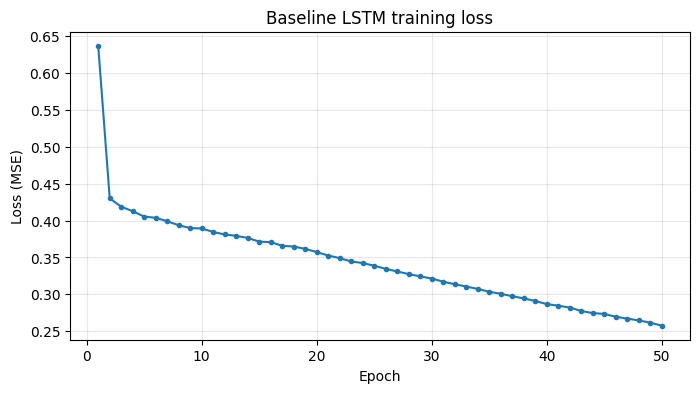

PASS: train_loss went from 0.6370 (epoch 1) to 0.2575 (epoch 50)
Epochs run: 50


In [ ]:
plot_training_loss(baseline_history, title='Baseline LSTM training loss')

In [ ]:
baseline_metrics, y_pred_baseline_test = evaluate_model(
    baseline_model, X_test_scaled, y_test, label='Baseline Test', device=device,
)

--- evaluate_model: Baseline Test ---
n:    7558
RMSE: 0.7874
MAE:  0.5999
R2:   0.6657


# V. Pilot timing

Inspect the projected best/worst-case grid runtime below before proceeding to Section VI -
especially on Colab, where a bad projection burns purchased compute units, not just idle local
time. Run this notebook interactively at least through this checkpoint on first execution.

In [ ]:
probe_df = estimate_grid_runtime(
    len(channels), X_train_scaled, y_train, X_validation_scaled, y_validation, device,
)
probe_df

--- estimate_grid_runtime: pilot timing ---
--- train_model: 3 epoch(s) run (ceiling 3) ---
Final train_loss: 0.4367
Final val_loss: 0.4225
cheapest (layers=1, hidden=16): 2.21 sec/epoch
--- train_model: 3 epoch(s) run (ceiling 3) ---
Final train_loss: 0.4344
Final val_loss: 0.5582
priciest (layers=4, hidden=256): 7.73 sec/epoch

Projected total grid runtime for 36 configs x up to 50 epochs each (ignores early-stopping savings - a real upper bound, not a decoration):
  Best case (all cheapest-rate):  66.3 min (1.10 hr)
  Worst case (all priciest-rate): 231.8 min (3.86 hr)


,num_layers,hidden_size,label,sec_per_epoch
0,1,16,cheapest,2.209432
1,4,256,priciest,7.726558


# VI. Grid search

Scores each of the 36 configs against the real held-out validation set. Results are written to
`lstm_grid_search_results.csv` after every config as a checkpoint against a dropped session.

In [ ]:
grid_results_df, grid_state_dicts = run_grid_search(
    input_size=len(channels), layer_grid=LAYER_GRID, unit_grid=UNIT_GRID, lr_grid=LR_GRID,
    X_train=X_train_scaled, y_train=y_train, X_val=X_validation_scaled, y_val=y_validation,
    device=device, epochs=EPOCHS, batch_size=BATCH_SIZE, patience=PATIENCE, min_delta=MIN_DELTA,
    seed=SEED, results_path=GRID_RESULTS_PATH,
)
grid_results_df.sort_values('val_rmse').reset_index(drop=True)

--- run_grid_search: 36 configs ---
--- train_model: 50 epoch(s) run (ceiling 50) ---
Final train_loss: 0.4083
Final val_loss: 0.4068 (best: 0.4052)
--- evaluate_model: Validation (config 1/36) ---
n:    9041
RMSE: 0.6366
MAE:  0.4881
R2:   0.7269
[1/36] layers=1 hidden=16 lr=1e-04 -> val_rmse=0.6366 epochs_run=50 elapsed=115.6s
--- train_model: 25 epoch(s) run (ceiling 50) ---
Final train_loss: 0.3950
Final val_loss: 0.3992 (best: 0.3975)
--- evaluate_model: Validation (config 2/36) ---
n:    9041
RMSE: 0.6305
MAE:  0.4827
R2:   0.7322
[2/36] layers=1 hidden=16 lr=1e-03 -> val_rmse=0.6305 epochs_run=25 elapsed=56.9s
--- train_model: 18 epoch(s) run (ceiling 50) ---
Final train_loss: 0.4057
Final val_loss: 0.4092 (best: 0.4062)
--- evaluate_model: Validation (config 3/36) ---
n:    9041
RMSE: 0.6374
MAE:  0.4873
R2:   0.7263
[3/36] layers=1 hidden=16 lr=1e-02 -> val_rmse=0.6374 epochs_run=18 elapsed=40.9s
--- train_model: 25 epoch(s) run (ceiling 50) ---
Final train_loss: 0.3977
Final 

,num_layers,hidden_size,lr,val_rmse,val_mae,val_r2,epochs_run,elapsed_sec,device
0,1,64,0.0010,0.626912,0.475402,0.735173,13,29.827853,cuda
1,1,256,0.0010,0.627589,0.479357,0.734600,14,42.377399,cuda
2,3,256,0.0001,0.627654,0.480536,0.734546,25,153.024148,cuda
3,3,64,0.0010,0.627769,0.478539,0.734448,13,42.082573,cuda
4,4,64,0.0001,0.627788,0.480233,0.734432,43,154.636580,cuda
5,2,64,0.0010,0.627797,0.478052,0.734424,17,47.280694,cuda
6,4,256,0.0001,0.628510,0.484222,0.733820,30,243.651799,cuda
7,2,16,0.0010,0.629062,0.481940,0.733353,27,72.614769,cuda
8,2,256,0.0010,0.629362,0.478803,0.733098,17,73.335674,cuda
9,4,64,0.0010,0.629646,0.484943,0.732858,20,70.916516,cuda


# VII. Select best config, load (not retrain), test evaluation

Loading the winning config's captured weights (instead of retraining from scratch with the same
seed) guarantees the shipped model is *exactly* the one that produced the recorded validation
score - no dependency on GPU training being bit-reproducible, and it skips an entire extra
training run.

In [ ]:
best_idx = grid_results_df['val_rmse'].idxmin()
best_row = grid_results_df.loc[best_idx]
print('Best config:')
print(best_row)

Best config:
num_layers             1
hidden_size           64
lr                 0.001
val_rmse        0.626912
val_mae         0.475402
val_r2          0.735173
epochs_run            13
elapsed_sec    29.827853
device              cuda
Name: 4, dtype: object


In [ ]:
final_model = LSTMRegressor(
    input_size=len(channels), hidden_size=int(best_row['hidden_size']),
    num_layers=int(best_row['num_layers']),
).to(device)
final_model.load_state_dict(grid_state_dicts[best_idx])
final_model.eval()

LSTMRegressor(
  (lstm): LSTM(22, 64, batch_first=True)
  (head): Linear(in_features=64, out_features=1, bias=True)
)

In [ ]:
# Confirmation - should reproduce best_row['val_rmse'] exactly, since these are the same weights
final_val_metrics, _ = evaluate_model(
    final_model, X_validation_scaled, y_validation, label='Tuned Validation (confirmation)',
    device=device,
)
assert np.isclose(final_val_metrics['rmse'], best_row['val_rmse'], atol=1e-6), (
    'Loaded weights do not reproduce the recorded grid-search validation score - '
    'investigate before trusting the test score below.'
)
print('Confirmed: loaded weights reproduce the recorded grid-search validation score exactly.')

--- evaluate_model: Tuned Validation (confirmation) ---
n:    9041
RMSE: 0.6269
MAE:  0.4754
R2:   0.7352
Confirmed: loaded weights reproduce the recorded grid-search validation score exactly.


In [ ]:
# The one and only test touch
final_test_metrics, y_pred_tuned_test = evaluate_model(
    final_model, X_test_scaled, y_test, label='Tuned Test', device=device,
)

--- evaluate_model: Tuned Test ---
n:    7558
RMSE: 0.6911
MAE:  0.5256
R2:   0.7425


# VIII. Results table

In [ ]:
baseline_config_str = f'layers={BASELINE_NUM_LAYERS},hidden={BASELINE_HIDDEN},lr={BASELINE_LR:.0e}'
best_config_str = (
    f"layers={int(best_row['num_layers'])},hidden={int(best_row['hidden_size'])},"
    f"lr={best_row['lr']:.0e}"
)

rows = [
    {'stage': 'baseline', 'model': 'LSTM baseline (untuned)', 'config': baseline_config_str,
     'device': str(device), **baseline_metrics},
    {'stage': 'validation', 'model': 'LSTM tuned', 'config': best_config_str,
     'device': str(device), **final_val_metrics},
    {'stage': 'test', 'model': 'LSTM baseline (untuned)', 'config': baseline_config_str,
     'device': str(device), **baseline_metrics},
    {'stage': 'test', 'model': 'LSTM tuned', 'config': best_config_str,
     'device': str(device), **final_test_metrics},
]
results_df = pd.DataFrame(rows)[['stage', 'model', 'config', 'device', 'n', 'rmse', 'mae', 'r2']]
results_df.to_csv(RESULTS_CSV_PATH, index=False)
print(f'Results saved to {RESULTS_CSV_PATH}')
results_df

NameError: name 'BASELINE_NUM_LAYERS' is not defined

# IX. Save models

The fitted scaler is persisted alongside both checkpoints so either model is usable standalone
later without needing to re-derive the exact training-time scaling (neither `07b` nor the
regression notebooks' raw checkpoints do this for the LSTM side). Both land in Drive automatically
under `platform == 'colab'` since `MODELS_DIR` is Drive-rooted in that branch.

In [ ]:
torch.save(baseline_model.state_dict(), MODELS_DIR / 'lstm_baseline_refreshed.pt')
torch.save(final_model.state_dict(), MODELS_DIR / 'lstm_tuned.pt')
joblib.dump(scaler, MODELS_DIR / 'lstm_scaler.pkl')

print(f"Baseline model saved to {MODELS_DIR / 'lstm_baseline_refreshed.pt'}")
print(f"Tuned model saved to {MODELS_DIR / 'lstm_tuned.pt'}")
print(f"Scaler saved to {MODELS_DIR / 'lstm_scaler.pkl'}")

Baseline model saved to /content/models/lstm_baseline_refreshed.pt
Tuned model saved to /content/models/lstm_tuned.pt
Scaler saved to /content/models/lstm_scaler.pkl


# X. Verification

## 1. Confirm dataset shapes match the current sequence pipeline output

In [ ]:
assert X_train.shape == (50497, 24, 22)
assert y_train.shape == (50497,)
assert X_validation.shape == (9041, 24, 22)
assert y_validation.shape == (9041,)
assert X_test.shape == (7558, 24, 22)
assert y_test.shape == (7558,)
assert len(channels) == 22
print('PASS: dataset shapes match the current lstm_{train,validation,test} pipeline output.')

PASS: dataset shapes match the current lstm_{train,validation,test} pipeline output.


## 2. Confirm the scaler produced ~zero mean / unit variance on train

In [ ]:
flat_scaled = X_train_scaled.reshape(-1, X_train_scaled.shape[-1])
print('Per-channel mean (should be ~0):', np.round(flat_scaled.mean(axis=0), 4))
print('Per-channel std (should be ~1):', np.round(flat_scaled.std(axis=0), 4))
assert np.allclose(flat_scaled.mean(axis=0), 0, atol=1e-3)
assert np.allclose(flat_scaled.std(axis=0), 1, atol=1e-2)
print('PASS: scaled train channels have ~zero mean / unit variance.')

Per-channel mean (should be ~0): [-0.     -0.      0.      0.     -0.      0.     -0.     -0.      0.
  0.      0.      0.     -0.     -0.     -0.     -0.      0.0001  0.
 -0.      0.     -0.      0.    ]
Per-channel std (should be ~1): [0.9996 0.9995 0.9995 0.9996 0.9996 0.9995 0.9996 0.9995 0.9995 0.9993
 0.9995 0.9994 0.9997 0.9997 0.9997 0.9996 0.9997 0.9996 1.     1.
 1.     1.0002]
PASS: scaled train channels have ~zero mean / unit variance.


## 3. Confirm saved checkpoints reload and reproduce identical predictions

In [ ]:
reloaded_baseline = LSTMRegressor(
    input_size=len(channels), hidden_size=BASELINE_HIDDEN, num_layers=BASELINE_NUM_LAYERS,
).to(device)
reloaded_baseline.load_state_dict(
    torch.load(MODELS_DIR / 'lstm_baseline_refreshed.pt', map_location=device)
)
reloaded_baseline.eval()

reloaded_final = LSTMRegressor(
    input_size=len(channels), hidden_size=int(best_row['hidden_size']),
    num_layers=int(best_row['num_layers']),
).to(device)
reloaded_final.load_state_dict(torch.load(MODELS_DIR / 'lstm_tuned.pt', map_location=device))
reloaded_final.eval()

with torch.no_grad():
    X_test_tensor = torch.from_numpy(X_test_scaled).float().to(device)
    y_pred_baseline_reloaded = reloaded_baseline(X_test_tensor).cpu().numpy().flatten()
    y_pred_tuned_reloaded = reloaded_final(X_test_tensor).cpu().numpy().flatten()

assert np.allclose(y_pred_baseline_reloaded, y_pred_baseline_test, atol=1e-5)
assert np.allclose(y_pred_tuned_reloaded, y_pred_tuned_test, atol=1e-5)
print('PASS: reloaded baseline and tuned models reproduce identical predictions to the in-memory models.')

PASS: reloaded baseline and tuned models reproduce identical predictions to the in-memory models.


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=4a18bf7d-431c-4909-af8a-a54a62228a78' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>